In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# --- Step 1: Load Data ---
file_path = "T20-GL-gainers-allSec-08-Jul-2025.csv"
df = pd.read_csv(file_path)

In [6]:
# --- Step 2: Clean and Prepare Data ---
df = df.dropna(subset=['%chng'])
df['daily_return'] = df['%chng'] / 100

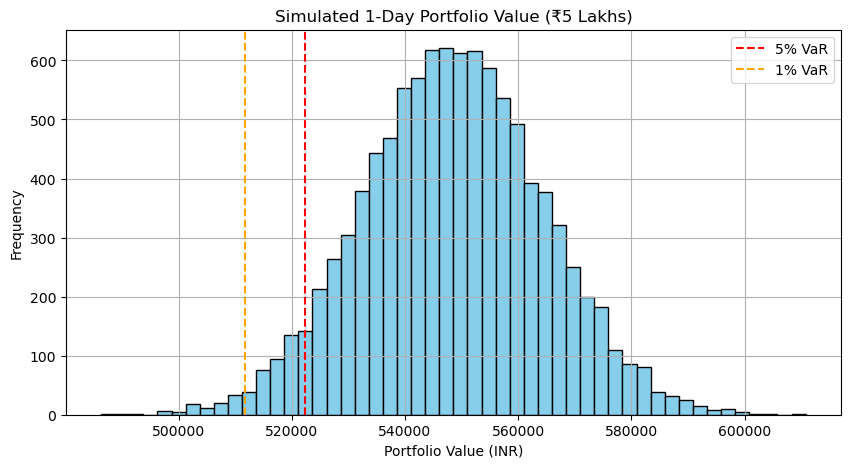

In [8]:
# --- Step 3: Monte Carlo Simulation (1 Day, ₹5 Lakhs Investment) ---
initial_investment = 5_00_000
mean_return = df['daily_return'].mean()
std_return = df['daily_return'].std()

np.random.seed(42)
simulated_returns = np.random.normal(loc=mean_return, scale=std_return, size=10000)
simulated_values = initial_investment * (1 + simulated_returns)

# Plot distribution
plt.figure(figsize=(10, 5))
plt.hist(simulated_values, bins=50, color='skyblue', edgecolor='black')
plt.axvline(x=np.percentile(simulated_values, 5), color='red', linestyle='--', label='5% VaR')
plt.axvline(x=np.percentile(simulated_values, 1), color='orange', linestyle='--', label='1% VaR')
plt.title("Simulated 1-Day Portfolio Value (₹5 Lakhs)")
plt.xlabel("Portfolio Value (INR)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Value at Risk Calculations
value_at_risk_5 = initial_investment - np.percentile(simulated_values, 5)
value_at_risk_1 = initial_investment - np.percentile(simulated_values, 1)
expected_loss = initial_investment - simulated_values.mean()

print(f"5% VaR: ₹{value_at_risk_5:,.0f}")
print(f"1% VaR: ₹{value_at_risk_1:,.0f}")
print(f"Expected Loss: ₹{expected_loss:,.0f}")

5% VaR: ₹-22,280
1% VaR: ₹-11,721
Expected Loss: ₹-48,496


In [12]:
# --- Step 4: Mean-Variance Portfolio (Using All Stocks) ---
# Generate synthetic returns using available daily return
symbols = df['AKI', 'SAMBHV', 'FILATFASH', 'CAPTRU-RE', 'NDLVENTURE', 'ELLEN', 'MSPL', 'TIMESGTY', 'ALOKINDS', 'BELRISE', 'PARSVNATH', 'RAMKY', 'WEL', 
'GABRIEL', 'BFUTILITIE', 'VAISHALI', 'FAZE3Q', 'DONEAR', 'DJML', 'YUKEN'].values
np.random.seed(42)
simulated_data = {
    symbol: np.random.normal(loc=row['daily_return'], scale=0.02, size=100)
    for symbol, row in df.set_index('AKI', 'SAMBHV', 'FILATFASH', 'CAPTRU-RE', 'NDLVENTURE', 'ELLEN', 'MSPL', 'TIMESGTY', 'ALOKINDS', 'BELRISE', 'PARSVNATH', 'RAMKY', 'WEL', 
'GABRIEL', 'BFUTILITIE', 'VAISHALI', 'FAZE3Q', 'DONEAR', 'DJML', 'YUKEN').iterrows()
}

returns_matrix = pd.DataFrame(simulated_data)

# Portfolio metrics
mean_returns = returns_matrix.mean()
cov_matrix = returns_matrix.cov()
weights = np.array([1 / len(mean_returns)] * len(mean_returns))

# Expected portfolio return and risk
portfolio_return = np.dot(weights, mean_returns)
portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
downside_returns = returns_matrix[returns_matrix < 0].fillna(0)
semi_deviation = np.sqrt((downside_returns**2).mean().mean())

print(f"Expected Daily Return: {portfolio_return:.4f}")
print(f"Portfolio Volatility: {portfolio_volatility:.4f}")
print(f"Downside Risk (Semi-Deviation): {semi_deviation:.4f}")

KeyError: ('AKI', 'SAMBHV', 'FILATFASH', 'CAPTRU-RE', 'NDLVENTURE', 'ELLEN', 'MSPL', 'TIMESGTY', 'ALOKINDS', 'BELRISE', 'PARSVNATH', 'RAMKY', 'WEL', 'GABRIEL', 'BFUTILITIE', 'VAISHALI', 'FAZE3Q', 'DONEAR', 'DJML', 'YUKEN')

In [14]:
# --- Mean-Variance Portfolio (All Stocks in File) ---

# Ensure daily_return is calculated
df = df.dropna(subset=['%chng'])
df['daily_return'] = df['%chng'] / 100

# Simulate synthetic return series for each stock
np.random.seed(42)
simulated_data = {
    row['Symbol']: np.random.normal(loc=row['daily_return'], scale=0.02, size=100)
    for _, row in df.iterrows()
}

# Create a DataFrame with simulated returns
returns_matrix = pd.DataFrame(simulated_data)

# Calculate portfolio metrics
mean_returns = returns_matrix.mean()
cov_matrix = returns_matrix.cov()

# Equal weights for all stocks
num_assets = len(mean_returns)
weights = np.array([1 / num_assets] * num_assets)

# Expected return and volatility
portfolio_return = np.dot(weights, mean_returns)
portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

# Downside risk (semi-deviation)
downside_returns = returns_matrix[returns_matrix < 0].fillna(0)
semi_deviation = np.sqrt((downside_returns ** 2).mean().mean())

# Print results
print(f"Expected Daily Return: {portfolio_return:.4f}")
print(f"Portfolio Volatility: {portfolio_volatility:.4f}")
print(f"Downside Risk (Semi-Deviation): {semi_deviation:.4f}")


Expected Daily Return: 0.0980
Portfolio Volatility: 0.0043
Downside Risk (Semi-Deviation): 0.0000


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
# --- Step 1: Load and Prepare Data ---
file_path = "T20-GL-gainers-allSec-08-Jul-2025.csv"
df = pd.read_csv(file_path)
df = df.dropna(subset=['%chng'])
df['daily_return'] = df['%chng'] / 100

# Assign dummy sectors
df['Sector'] = pd.cut(df.index, bins=5, labels=['Sector A', 'Sector B', 'Sector C', 'Sector D', 'Sector E'])

In [20]:
# --- Step 2: Simulate Returns ---
np.random.seed(42)
simulated_data = {
    row['Symbol']: np.random.normal(loc=row['daily_return'], scale=0.02, size=100)
    for _, row in df.iterrows()
}
returns_df = pd.DataFrame(simulated_data)

In [22]:
# --- Step 3: Portfolio Metrics ---
mean_returns = returns_df.mean()
volatility = returns_df.std()
downside = returns_df.copy()
downside[downside > 0] = 0
semi_deviation = np.sqrt((downside ** 2).mean())

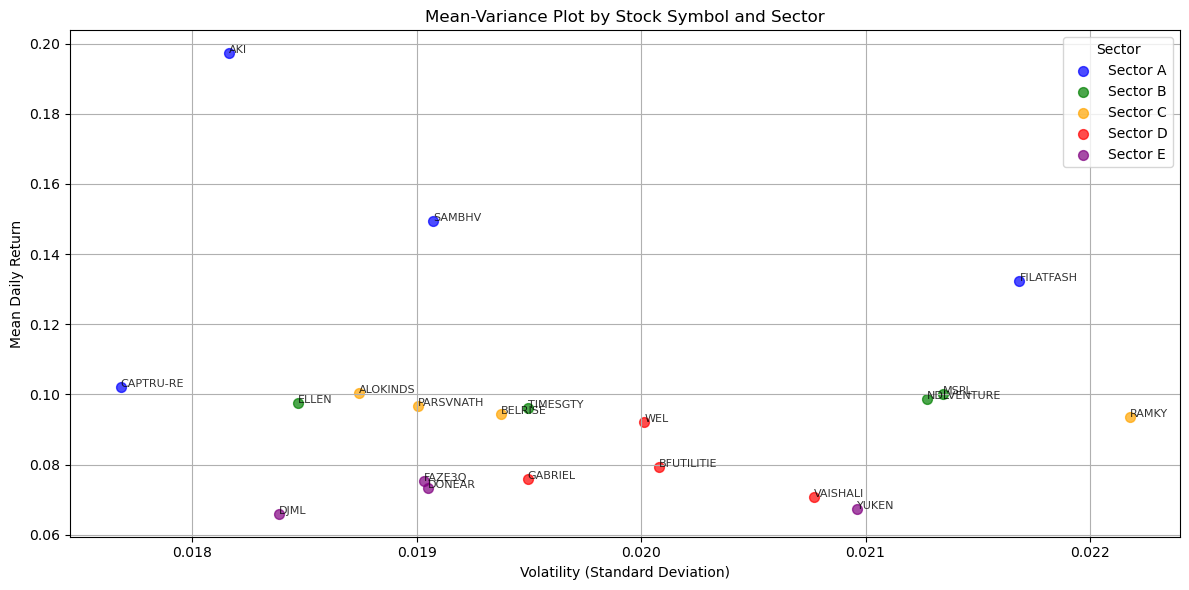

In [24]:
# --- Step 4: Sector Color Map for Mean-Variance Plot ---
sector_map = df.set_index('Symbol')['Sector'].to_dict()
sector_colors = {'Sector A': 'blue', 'Sector B': 'green', 'Sector C': 'orange', 'Sector D': 'red', 'Sector E': 'purple'}

plt.figure(figsize=(12, 6))
for symbol in returns_df.columns:
    sector = sector_map[symbol]
    plt.scatter(volatility[symbol], mean_returns[symbol], label=sector if symbol == df[df['Sector'] == sector]['Symbol'].values[0] else "", 
                color=sector_colors[sector], s=50, alpha=0.7)
    plt.text(volatility[symbol], mean_returns[symbol], symbol, fontsize=8, alpha=0.8)

plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Mean Daily Return')
plt.title('Mean-Variance Plot by Stock Symbol and Sector')
plt.grid(True)
plt.legend(title='Sector')
plt.tight_layout()
plt.show()

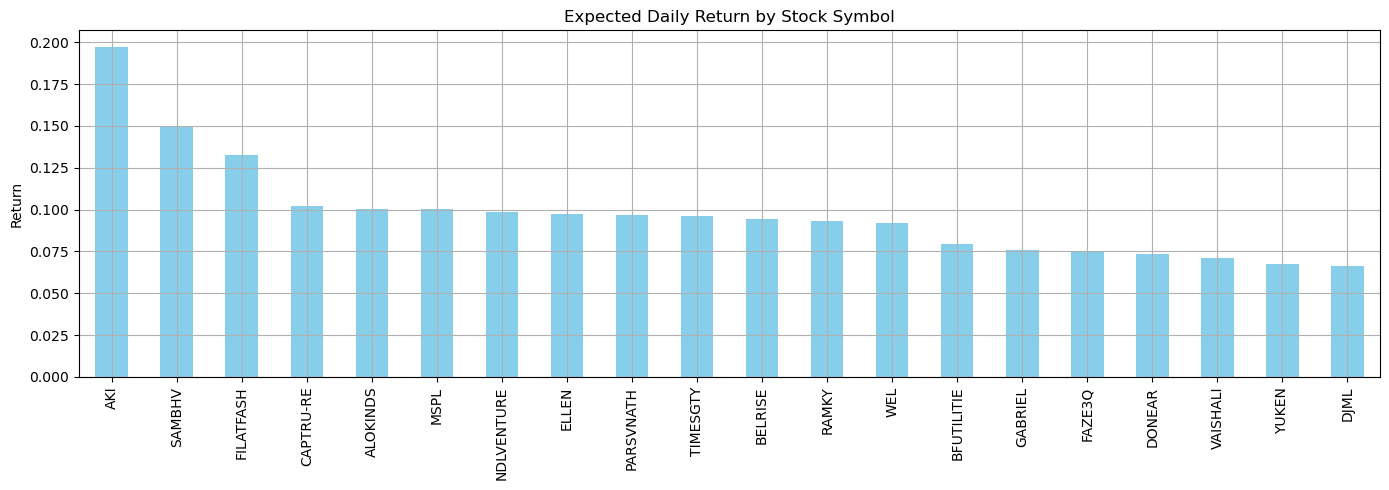

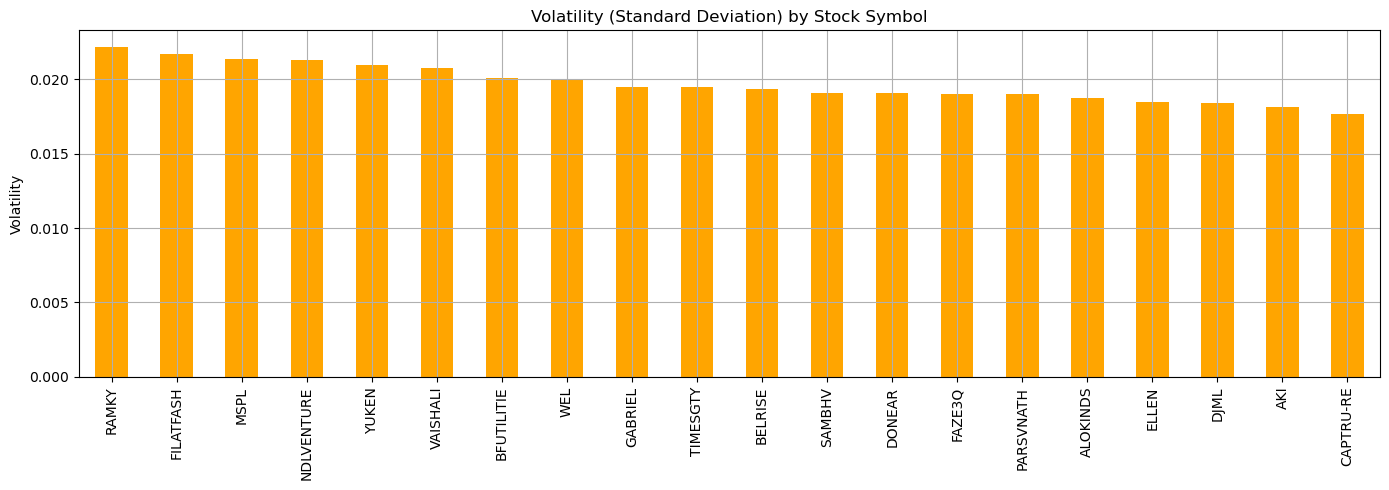

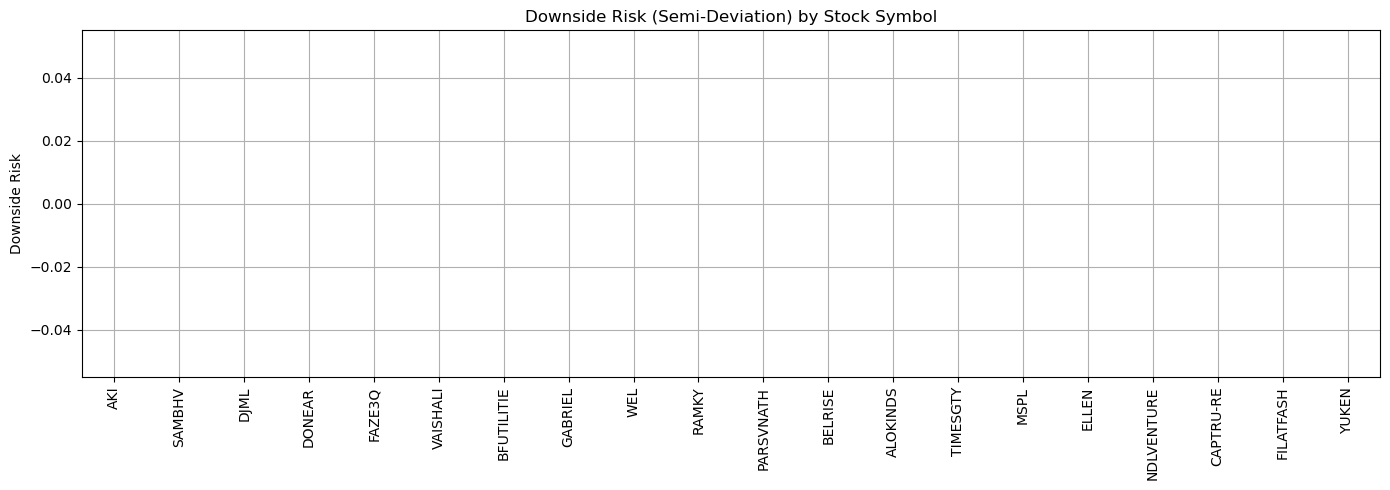

In [26]:
# --- Step 5: Individual Metric Bar Charts ---
plt.figure(figsize=(14, 5))
mean_returns.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Expected Daily Return by Stock Symbol')
plt.ylabel('Return')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
volatility.sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Volatility (Standard Deviation) by Stock Symbol')
plt.ylabel('Volatility')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
semi_deviation.sort_values(ascending=False).plot(kind='bar', color='red')
plt.title('Downside Risk (Semi-Deviation) by Stock Symbol')
plt.ylabel('Downside Risk')
plt.grid(True)
plt.tight_layout()
plt.show()